<a href="https://colab.research.google.com/github/maggieshiro384-art/CDAV/blob/main/Loan_dataset_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
loan_data=pd.read_csv("/content/loan_data.csv")

In [52]:
loan_data.head(15)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
5,LP001024,Male,Yes,2,Graduate,No,3200,700.0,70.0,360.0,1.0,Urban,Y
6,LP001027,Male,Yes,2,Graduate,No,2500,1840.0,109.0,360.0,1.0,Urban,Y
7,LP001029,Male,No,0,Graduate,No,1853,2840.0,114.0,360.0,1.0,Rural,N
8,LP001030,Male,Yes,2,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,Y
9,LP001032,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y


In [24]:
loan_data.shape

(381, 13)

In [25]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [26]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [27]:
loan_data.isna().sum()


,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [28]:
loan_data.isnull().mean() * 100

,0
Loan_ID,0.000000
Gender,1.312336
Married,0.000000
Dependents,2.099738
Education,0.000000
Self_Employed,5.511811
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,0.000000
Loan_Amount_Term,2.887139


In [29]:
loan_data.duplicated().sum()

np.int64(0)

#Data Cleaning

In [36]:
#Cleaning the Gender Column
loan_data["Gender"].unique()





array(['Male', 'Female', nan], dtype=object)

In [37]:

loan_data["Gender"].mode()

,Gender
0,Male


In [44]:
# filled the nall values with mode
loan_data["Gender"]=loan_data["Gender"].fillna("Male")

In [39]:
#Cleaning the dependents Column
loan_data["Dependents"].mode()

,Dependents
0,0


In [45]:
#filled the nall values with mode
loan_data["Dependents"]=loan_data["Dependents"].fillna("0")

In [41]:
#Cleaning the self_employed column
loan_data["Self_Employed"].mode()

,Self_Employed
0,No


In [46]:
#Filled the nall values with mode
loan_data["Self_Employed"]=loan_data["Self_Employed"].fillna("No")

In [48]:
#Cleaning Loan_Amount_Term
loan_data["Loan_Amount_Term"].median()

360.0

In [50]:
#filled the nall values with median since its not affected by outliers
loan_data["Loan_Amount_Term"]=loan_data["Loan_Amount_Term"].fillna(360)

In [51]:
#Cleaning Credit_History
loan_data["Credit_History"].median()

1.0

In [53]:
#filled the nall values with median since its not affected by outliers
loan_data["Credit_History"]=loan_data["Credit_History"].fillna(1.0)

In [54]:
#No missing values
loan_data.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# 1.Understanding the dataset
The dataset contains 381 loan applications and 13 variables, providing information about the applicants, their financial characteristics, loan details, and loan approval outcomes. The variables are classified into numerical and categorical variables. The numerical variables include applicant income, co-applicant income, loan amount, loan repayment term, and credit history. Applicant income and co-applicant income represent the earnings of the main applicant and co-applicant respectively, while loan amount represents the amount requested by the applicant. Loan amount term indicates the repayment period, and credit history is a binary variable showing whether the applicant meets the required credit history criteria. The categorical variables include gender, marital status, number of dependants, education level, self-employment status, property area, and loan status. These variables provide information about the applicants' demographic and socioeconomic characteristics, as well as whether their loan applications were approved or rejected. Loan-ID is treated as an identifier because it uniquely identifies each application and does not provide meaningful information for statistical analysis.





#2.Describe the applicants.
Using appropriate measures of central tendency and variation, describe applicant income, co-applicant income and loan amount. Interpret the results rather than simply reporting the numbers.

##Applicant Income

The mean applicant income is 3,579.85, while the median applicant income is 3,333. This means that the average applicant income is 3,579.85, while half of the applicants earn below 3,333 and half earn above 3,333. Since the mean is higher than the median, some applicants with higher incomes are likely pulling the average upward. The standard deviation of 1,419.81 indicates considerable variation in applicant incomes. The Q1 of 2,600 means that 25% of applicants have incomes of 2,600 or less, while the Q3 of 4,288 means that 75% of applicants have incomes of 4,288 or less. Therefore, the middle 50% of applicants have incomes between 2,600 and 4,288.

##Co-applicant Income

The mean co-applicant income is 1,277.28, while the median co-applicant income is 983. This means that the average co-applicant income is 1,277.28, while half of the co-applicants have incomes below 983 and half have incomes above 983. The difference between the mean and median suggests that some co-applicants have relatively high incomes that increase the average. The standard deviation of 2,340.82 is very large compared with the mean, indicating that co-applicant incomes vary substantially across applicants. The Q1 of 0 indicates that 25% of the observations have no co-applicant income, while the Q3 of 2,016 means that 75% have a co-applicant income of 2,016 or less. Thus, the middle 50% of co-applicant incomes fall between 0 and 2,016.

##Loan Amount

The mean loan amount is 104.99, while the median loan amount is 110. This means that the average loan amount is 104.99, while half of the applicants requested a loan amount below 110 and half requested an amount above 110. The standard deviation of 28.36 shows that loan amounts have relatively moderate variation compared with the income variables. The Q1 of 90 means that 25% of applicants requested a loan amount of 90 or less, while the Q3 of 127 means that 75% of applicants requested a loan amount of 127 or less. Therefore, the middle 50% of loan amounts fall between 90 and 127.



#3.Investigate the distributions.

##ApplicantIncome

The mean applicant income is 3,579.85, while the median is 3,333. Since the mean is higher than the median, the distribution is positively (right) skewed. This suggests that some applicants have relatively high incomes that pull the mean upward.

The standard deviation of 1,419.81 indicates considerable variation in applicant incomes. The middle 50% of incomes lie between Q1 = 2,600 and Q3 = 4,288. Because the distribution is skewed and affected by high values, the median of 3,333 is more appropriate for describing the typical applicant income.

##CoapplicantIncome

The mean co-applicant income is 1,277.28, compared with a median of 983. The mean being considerably higher than the median indicates a positive (right) skew. Some co-applicants have very high incomes, which pull the mean upward.

The standard deviation is 2,340.82, which is very large relative to the mean, showing substantial variation in co-applicant income. Also, Q1 is 0, while Q3 is 2,016, meaning the middle 50% of co-applicant incomes range from 0 to 2,016. Therefore, the median of 983 is more appropriate for describing the typical co-applicant income.

##LoanAmount

The mean loan amount is 104.99, while the median is 110. Since the mean is slightly lower than the median, the distribution is slightly negatively (left) skewed. This suggests that some unusually small loan amounts pull the mean downward.

The standard deviation of 28.36 indicates moderate variation in loan amounts. The middle 50% of loan amounts fall between Q1 = 90 and Q3 = 127. Because of the slight skewness and the presence of unusually small loan amounts, the median of 110 is more appropriate for representing the typical loan amount.

In [60]:
summary = loan_data[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].describe()

summary = summary.loc[["mean", "50%", "std", "25%", "75%"]] # calculates the mean,std, median and quartiles of the selected columns

summary.index = ["Mean", "Median", "Std. Dev.", "Q1", "Q3"] # Used .index to rename 50% as Median because the 50th percentile is the median

summary

,ApplicantIncome,CoapplicantIncome,LoanAmount
Mean,3579.845144,1277.275381,104.986877
Median,3333.000000,983.000000,110.000000
Std. Dev.,1419.813818,2340.818114,28.358464
Q1,2600.000000,0.000000,90.000000
Q3,4288.000000,2016.000000,127.000000


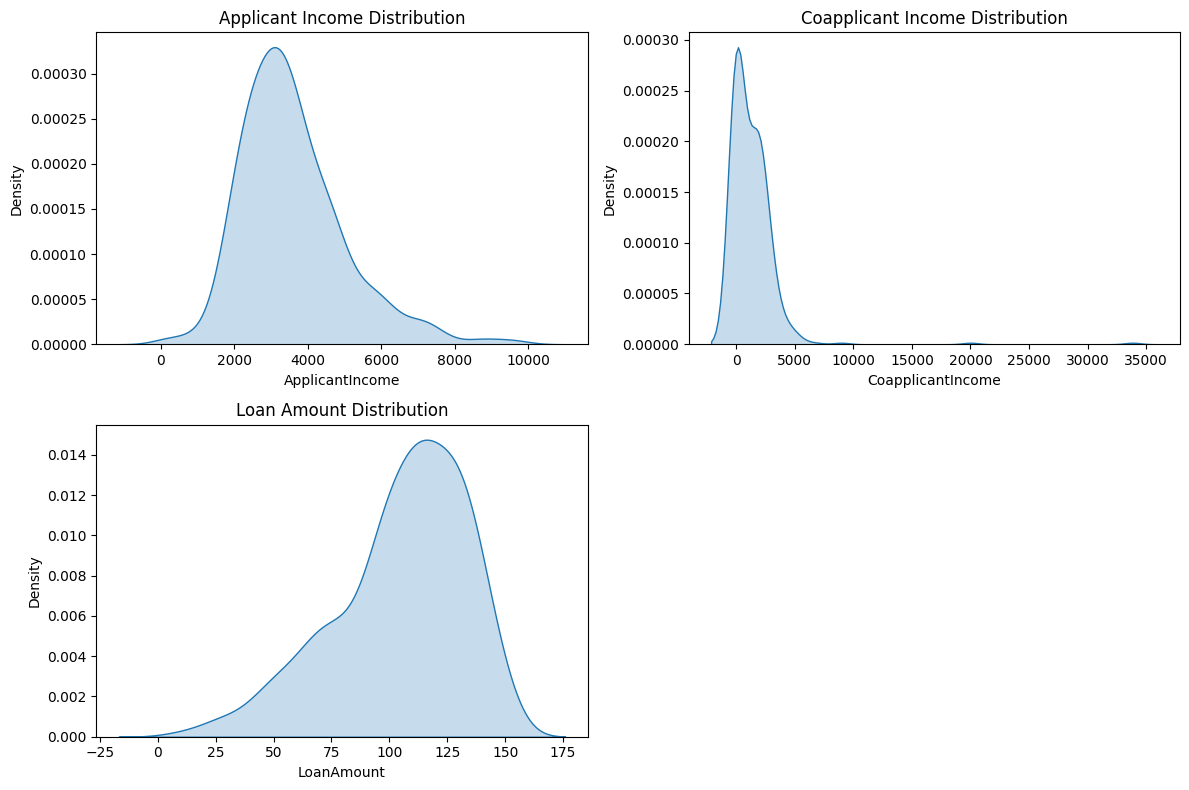

In [82]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(data=loan_data, x="ApplicantIncome", fill=True, ax=ax[0, 0])
ax[0, 0].set_title("Applicant Income Distribution")

sns.kdeplot(data=loan_data, x="CoapplicantIncome", fill=True, ax=ax[0, 1])
ax[0, 1].set_title("Coapplicant Income Distribution")

sns.kdeplot(data=loan_data, x="LoanAmount", fill=True, ax=ax[1, 0])
ax[1, 0].set_title("Loan Amount Distribution")

ax[1, 1].axis("off")

plt.tight_layout()
plt.show()

#4.Investigate outliers.
Use the IQR method and appropriate visualizations to determine whether there are outliers in ApplicantIncome and LoanAmount.

##Applicant Income

The IQR analysis identified 14 outliers in ApplicantIncome, with values ranging from 6,822 to 9,703. All these values are above the calculated upper bound of 6,820, indicating that they represent unusually high applicant incomes compared with the majority of the applicants.

##Loan Amount

The IQR analysis identified 7 outliers in LoanAmount. These values range from 9 to 30, and they are all below the calculated lower bound of 34.5. This indicates that these applicants requested unusually small loan amounts compared with the majority of applicants.

This is also well visualized with the boxplot and we can as well see outliers.

The typical loan amount requested is 110, based on the median (Q2).

For LoanAmount:

Q1 = 90
Median (Q2) = 110
Q3 = 127
IQR = 37

The first quartile (Q1) is 90, meaning that 25% of applicants requested a loan amount of 90 or less, while 75% requested more than 90.

The median (Q2) is 110, meaning that 50% of applicants requested 110 or less, while the other 50% requested 110 or more. Therefore, 110 represents the typical loan amount requested.

The third quartile (Q3) is 127, meaning that 75% of applicants requested a loan amount of 127 or less, while the remaining 25% requested more than 127.


#5.Describe the loan applications.

What is the typical loan amount requested? Calculate and interpret the quartiles and IQR for LoanAmount. What do Q1, the median and Q3 tell you about the loan amounts requested?


The typical loan amount requested is 110, based on the median (Q2).

The first quartile (Q1) is 90, meaning that 25% of applicants requested a loan amount of 90 or less, while 75% requested more than 90.

The median (Q2) is 110, meaning that 50% of applicants requested 110 or less, while the other 50% requested 110 or more. Therefore, 110 represents the typical loan amount requested.

The third quartile (Q3) is 127, meaning that 75% of applicants requested a loan amount of 127 or less, while the remaining 25% requested more than 127.This means that the middle 50% of loan amounts requested fall between 90 and 127, giving a spread of 37. Overall, the loan amounts are relatively concentrated around the median of 110




In [63]:
summary = loan_data[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].describe()

iqr_table = summary.loc[["25%", "50%", "75%"]]

iqr_table.index = ["Q1", "Median (Q2)", "Q3"]

iqr_table.loc["IQR"] = iqr_table.loc["Q3"] - iqr_table.loc["Q1"]

iqr_table.loc["Lower Bound"] = iqr_table.loc["Q1"] - (1.5 * iqr_table.loc["IQR"])

iqr_table.loc["Upper Bound"] = iqr_table.loc["Q3"] + (1.5 * iqr_table.loc["IQR"])

iqr_table

,ApplicantIncome,CoapplicantIncome,LoanAmount
Q1,2600.0,0.0,90.0
Median (Q2),3333.0,983.0,110.0
Q3,4288.0,2016.0,127.0
IQR,1688.0,2016.0,37.0
Lower Bound,68.0,-3024.0,34.5
Upper Bound,6820.0,5040.0,182.5


In [67]:
print("outliers, ApplicantIncome:",(loan_data["ApplicantIncome"] < 68).sum() + (loan_data["ApplicantIncome"] > 6820).sum())

print("outliers, loanAmount:",(loan_data["LoanAmount"] < 34.5).sum() + (loan_data["LoanAmount"] > 182.5).sum())

outliers, ApplicantIncome: 14
outliers, loanAmount: 7


In [69]:
Q1 = loan_data["ApplicantIncome"].quantile(0.25)
Q3 = loan_data["ApplicantIncome"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

applicant_outliers = loan_data[
    (loan_data["ApplicantIncome"] < lower_bound) |
    (loan_data["ApplicantIncome"] > upper_bound)
]["ApplicantIncome"].values

applicant_outliers

array([7660, 7100, 7333, 9323, 9703, 7200, 6822, 8750, 7167, 7250, 8624,
       7142, 7085, 7740])

In [70]:
Q1 = loan_data["LoanAmount"].quantile(0.25)
Q3 = loan_data["LoanAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

loan_outliers = loan_data[
    (loan_data["LoanAmount"] < lower_bound) |
    (loan_data["LoanAmount"] > upper_bound)
]["LoanAmount"].values

loan_outliers

array([17., 25., 25., 30., 30., 26.,  9.])

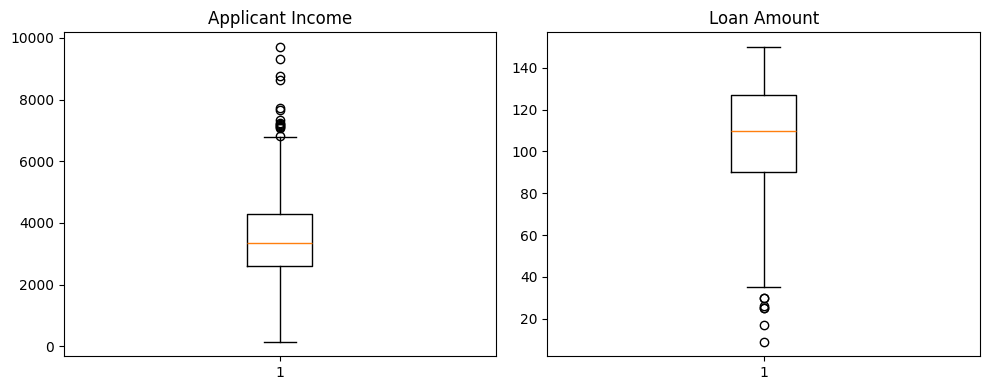

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].boxplot(loan_data["ApplicantIncome"])
ax[0].set_title("Applicant Income")

ax[1].boxplot(loan_data["LoanAmount"])
ax[1].set_title("Loan Amount")

plt.tight_layout()
plt.show()

#6.Investigate relationships between numerical variables.
Calculate correlations among appropriate numerical variables such as ApplicantIncome, CoapplicantIncome, and LoanAmount. Which variables have the strongest relationship? State both the direction and strength of the relationship. Use a scatter plot to investigate at least one relationship.

The strongest relationship is between ApplicantIncome and LoanAmount, with a correlation coefficient of 0.27. This represents a weak positive relationship, meaning that applicants with higher incomes tend to request slightly higher loan amounts, although the relationship is not strong.

The relationship between ApplicantIncome and CoapplicantIncome has a correlation of -0.25, indicating a weak negative relationship. This suggests that applicants with higher incomes tend to have slightly lower co-applicant incomes, although the association is weak.

The relationship between CoapplicantIncome and LoanAmount has a correlation of 0.11, which represents a very weak positive relationship. This indicates little linear association between co-applicant income and the amount of loan requested.

The scatter plot shows the relationship between ApplicantIncome and LoanAmount. There is a slight upward pattern in the points, which indicates a positive relationship: as applicant income increases, loan amounts tend to increase slightly.

However, the points are widely scattered, which is consistent with the correlation coefficient of 0.27. Therefore, the relationship is weak, meaning that applicant income does not strongly determine the loan amount requested.

In [71]:
correlation = loan_data[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].corr().round(2) #rounds off to 2decimal places

correlation

,ApplicantIncome,CoapplicantIncome,LoanAmount
ApplicantIncome,1.00,-0.25,0.27
CoapplicantIncome,-0.25,1.00,0.11
LoanAmount,0.27,0.11,1.00


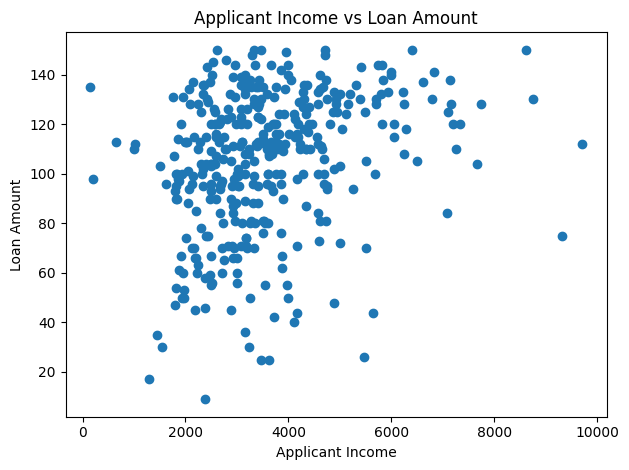

In [72]:
plt.scatter(loan_data["ApplicantIncome"], loan_data["LoanAmount"])

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Applicant Income vs Loan Amount")

plt.tight_layout()
plt.show()

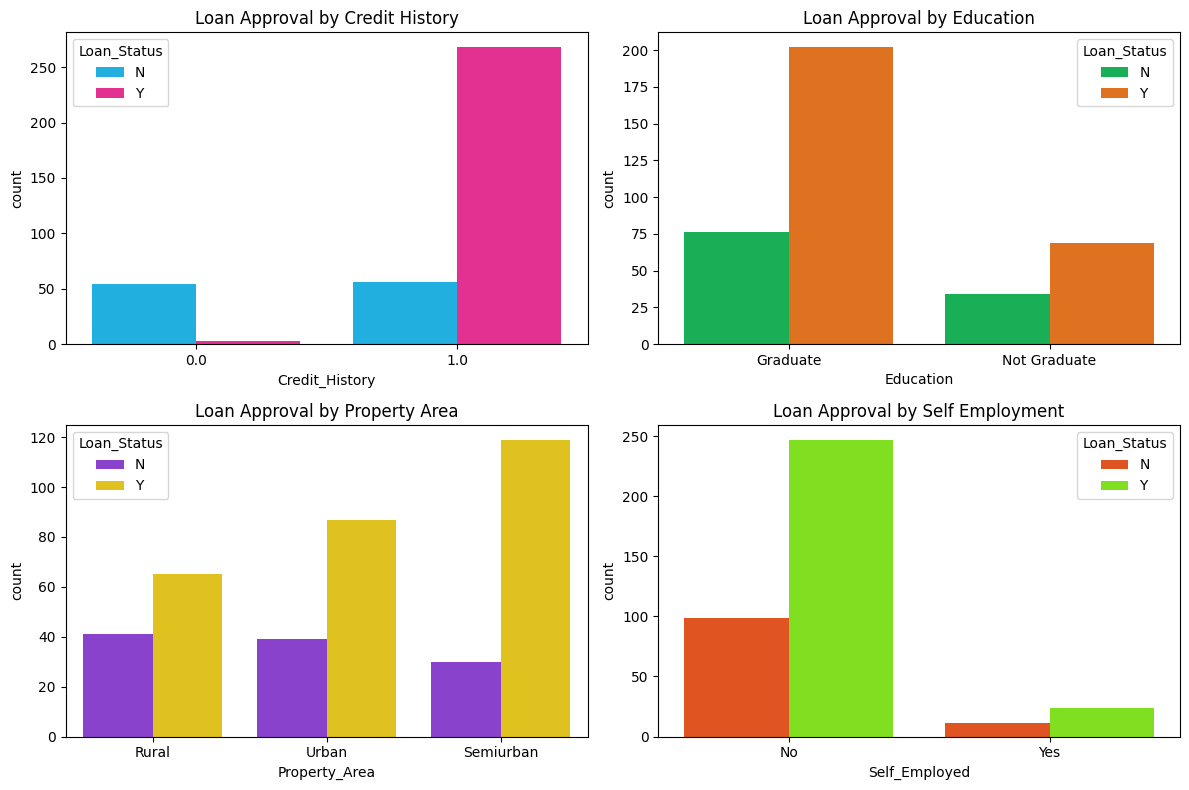

In [81]:


fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=loan_data, x="Credit_History", hue="Loan_Status",
              palette=["#00BFFF", "#FF1493"], ax=ax[0, 0])
ax[0, 0].set_title("Loan Approval by Credit History")

sns.countplot(data=loan_data, x="Education", hue="Loan_Status",
              palette=["#00C853", "#FF6D00"], ax=ax[0, 1])
ax[0, 1].set_title("Loan Approval by Education")

sns.countplot(data=loan_data, x="Property_Area", hue="Loan_Status",
              palette=["#8A2BE2", "#FFD700"], ax=ax[1, 0])
ax[1, 0].set_title("Loan Approval by Property Area")

sns.countplot(data=loan_data, x="Self_Employed", hue="Loan_Status",
              palette=["#FF4500", "#7FFF00"], ax=ax[1, 1])
ax[1, 1].set_title("Loan Approval by Self Employment")

plt.tight_layout()
plt.show()

Key Insights for Bank Management
1. Credit history is the strongest approval-related factor

The Loan Approval by Credit History visualization shows a substantially higher number of approvals among applicants with a positive credit history (Credit_History = 1) compared with those without one (Credit_History = 0).
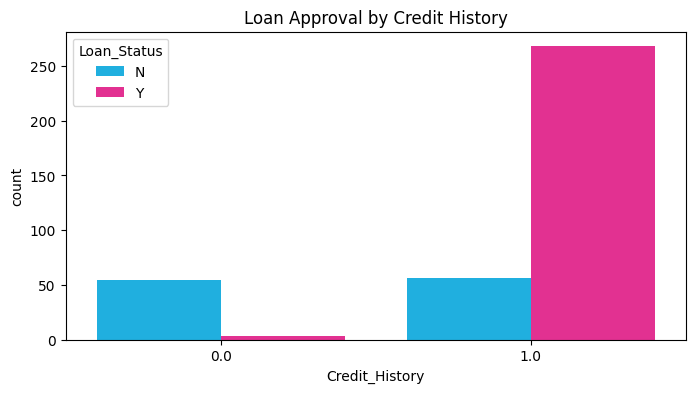

Management insight:
This suggests that credit history is an important indicator of loan repayment risk. The bank should therefore continue to place significant emphasis on applicants' previous credit behaviour when assessing loan applications. However, credit history should be considered alongside income, loan amount, and other applicant characteristics rather than being used as the sole approval criterion.

2. The applicant base contains a financially diverse group of borrowers

ApplicantIncome has a mean of 3,579.85, a median of 3,333, and a standard deviation of 1,419.81. The KDE plot shows a right-skewed distribution, while the IQR analysis identified 14 unusually high-income applicants ranging from 6,822 to 9,703.

Management insight:
The bank is serving customers with substantially different income levels. This suggests an opportunity for income-based customer segmentation, where loan products, limits, and repayment terms can be tailored to different income groups. High-income applicants may potentially qualify for larger loans, subject to affordability and credit-risk assessment.

3. Co-applicant income provides an important but highly variable source of repayment capacity

CoapplicantIncome has a median of 983, while Q1 = 0 and Q3 = 2,016. Its standard deviation of 2,340.82 is particularly high, indicating substantial variation. The KDE plot also shows strong positive skewness.

Management insight:
A significant portion of applications have little or no co-applicant income, while others have considerably higher co-applicant earnings. This means the bank should not assume that co-applicant income provides the same level of repayment support across applications. Assessing the combined and individual income sources could improve affordability and risk assessment.

4. Loan demand is relatively concentrated, but unusually small requests require attention

The median LoanAmount is 110, with Q1 = 90 and Q3 = 127, giving an IQR of 37. Therefore, the middle 50% of applicants request amounts between 90 and 127. However, the IQR analysis identified 7 unusually small loan amounts ranging from 9 to 30.

Management insight:
Most customers are requesting loans within a relatively predictable range, which can help the bank design standard loan products around common borrowing levels. The unusually small requests could represent customers with different financial needs and may be suitable for smaller, simplified loan products rather than being assessed using exactly the same process as larger loans.

5. Income alone is not sufficient for determining the appropriate loan amount

The correlation between ApplicantIncome and LoanAmount is only 0.27, indicating a weak positive relationship. The scatter plot also shows considerable dispersion rather than a strong linear pattern.

Management insight:
Higher-income applicants do tend to request somewhat larger loans, but the weak relationship shows that income alone does not explain the amount customers borrow. Therefore, a bank should avoid using income as the only basis for setting loan limits. Other factors such as credit history, existing obligations, property area, employment status, and the purpose of the loan should also be considered.

Overall Conclusion for Bank Managers

The analysis suggests that the bank's applicants are financially diverse, with considerable variation in applicant and co-applicant incomes, while most loan requests are concentrated around 110. The most important lending signal identified in the categorical analysis is credit history, while the weak correlation between income and loan amount indicates that borrowing needs cannot be predicted from income alone.

From a management perspective, the findings support a risk-based lending approach: use credit history as an important risk indicator, assess the applicant's overall repayment capacity, segment customers according to their financial profiles, and avoid relying on a single variable when determining loan approval or loan limits.